CheckPoint 1

In [164]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [165]:
df=pd.read_csv('marketing_AB.csv', sep=None, engine='python', index_col=0)

In [166]:
df.head()

,user id,test group,converted,total ads,most ads day,most ads hour
0,1069124,ad,False,130,Monday,20
1,1119715,ad,False,93,Tuesday,22
2,1144181,ad,False,21,Tuesday,18
3,1435133,ad,False,355,Tuesday,10
4,1015700,ad,False,276,Friday,14


In [167]:
df["test group"].value_counts()

test group
ad     564577
psa     23524
Name: count, dtype: int64

In [168]:
group_stats = df.groupby("test group")["total ads"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

group_stats

,count,mean,median,std,min,max
test group,,,,,,
ad,564577,24.823365,13.0,43.750456,1,2065
psa,23524,24.761138,12.0,42.860720,1,907


In [169]:
df.groupby("test group")["total ads"].describe()

,count,mean,std,min,25%,50%,75%,max
test group,,,,,,,,
ad,564577.0,24.823365,43.750456,1.0,4.0,13.0,27.0,2065.0
psa,23524.0,24.761138,42.860720,1.0,4.0,12.0,26.0,907.0


In [170]:
conversion_rate = df.groupby("test group")["converted"].mean().mul(100).round(2)
conversion_rate

test group
ad     2.55
psa    1.79
Name: converted, dtype: float64

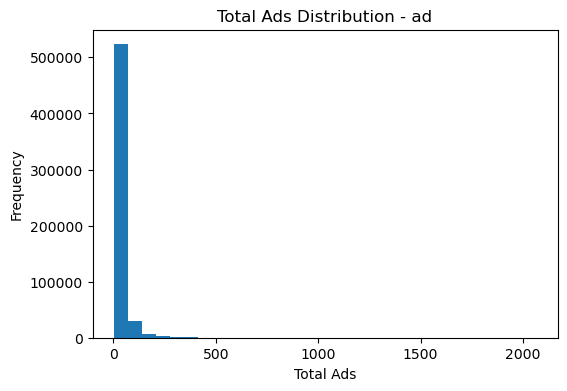

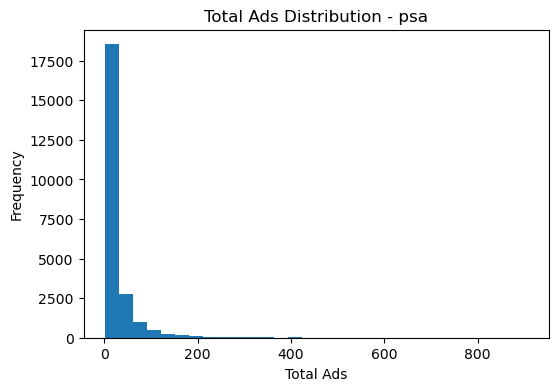

In [171]:
for group in df["test group"].unique():
    plt.figure(figsize=(6,4))
    plt.hist(
        df[df["test group"] == group]["total ads"],
        bins=30
    )
    plt.title(f"Total Ads Distribution - {group}")
    plt.xlabel("Total Ads")
    plt.ylabel("Frequency")
    plt.show()

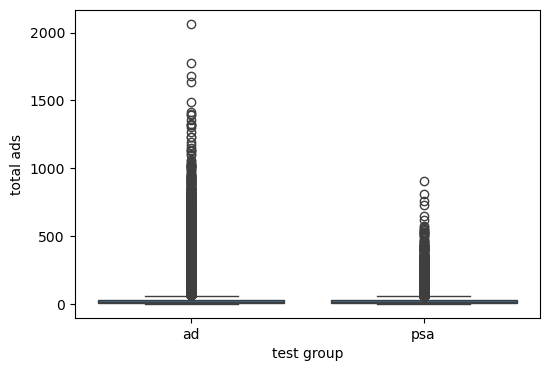

In [172]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x="test group",
    y="total ads"
)

plt.show()

In [173]:
from scipy.stats import skew

skewness = df.groupby("test group")["total ads"].apply(skew)
skewness

test group
ad     7.502722
psa    5.650863
Name: total ads, dtype: float64

In [174]:
#Bu hissədə məlumatları 'test group' sütununa görə qruplaşdırdım və hər qrup üçün təsviri statistikanı hesabladım.
#  'Total ads'  üzrə orta, median, standart sapma, minimum və maksimum dəyərlərə baxdım. Daha sonra 'converted' sütunundan 
# istifadə edərək hər qrupun conversion rate-ni hesabladım. Paylanmanın formasını qiymətləndirmək üçün histogram, boxplot və 
# skewness göstəricisindən istifadə etdim.

CheckPoint 2

In [175]:
#Bu mərhələdə analiz zamanı cavablandırmaq istədiyim iki biznes sualını tapdım və hər biri üçün null (H0) və alternativ (H1) hipotezlərini qurdum. 
#Növbəti mərhələdə bu hipotezləri uyğun statistik testlərlə yoxlayacağam.

#Biznes sualı 1 : Reklam göstərilən istifadəçilərin (ad qrupu) conversion rate-i PSA qrupundan fərqlənirmi?

#H0: Null hipotez: Ad və PSA qruplarının conversion rate-ləri arasında statistik cəhətdən əhəmiyyətli fərq yoxdur.
#H1: Alternativ hipotez: Ad və PSA qruplarının conversion rate-ləri arasında statistik cəhətdən əhəmiyyətli fərq var.

#Biznes sualı 2: Ad və PSA qruplarında istifadəçilərin gördüyü orta reklam sayı (`total ads`) fərqlənirmi?

#H0: Null hipotez: Ad və PSA qruplarının orta `total ads` dəyərləri arasında statistik cəhətdən əhəmiyyətli fərq yoxdur.
#H1: Alternativ hipotez: Ad və PSA qruplarının orta `total ads` dəyərləri arasında statistik cəhətdən əhəmiyyətli fərq var.

CheckPoint 3

In [176]:
from scipy.stats import chi2_contingency
contingency = pd.crosstab(df["test group"], df["converted"])
contingency

converted,False,True
test group,,
ad,550154,14423
psa,23104,420


In [177]:
chi2, p, dof, expected = chi2_contingency(contingency)

print("Chi-square statistic:", chi2)
print("P-value:", p)
print("Degrees of freedom:", dof)

Chi-square statistic: 54.005823883685245
P-value: 1.9989623063390075e-13
Degrees of freedom: 1


In [178]:
from scipy.stats import ttest_ind

ad = df[df["test group"] == "ad"]["total ads"]
psa = df[df["test group"] == "psa"]["total ads"]

t_stat, p = ttest_ind(ad, psa)

print("T-statistic:", t_stat)
print("P-value:", p)

T-statistic: 0.21391499762385457
P-value: 0.8306134186810267


In [179]:
# p < 0.05 olduğu üçün H0 rədd olunur -> ad və psa qruplarının conversion rate-i arasında 
# statistik cəhətdən əhəmiyyətli fərq var.

# T-test nəticəsi (total ads üzrə):
# t-stat = 0.214, p-value = 0.83
# p > 0.05 olduğu üçün H0 rədd edilmir -> ad və psa qruplarının orta total ads dəyərləri 
# arasında statistik cəhətdən əhəmiyyətli fərq tapılmadı.

# Test seçimi izahı: 'converted' sütunu binary (True/False) kateqorik dəyişən olduğu üçün 
# iki qrup arasındakı əlaqəni yoxlamaq üçün Chi-square test of independence istifadə etdim. 
# 'total ads' isə davamlı (continuous) dəyişən olduğu üçün iki qrupun ortalamalarını 
# müqayisə etmək məqsədilə independent samples t-test seçdim.

CheckPoint 4

In [180]:
from statsmodels.stats.proportion import proportion_confint

ad_converted = df[df["test group"] == "ad"]["converted"]
psa_converted = df[df["test group"] == "psa"]["converted"]

ci_ad = proportion_confint(ad_converted.sum(), len(ad_converted), method="wilson")
ci_psa = proportion_confint(psa_converted.sum(), len(psa_converted), method="wilson")

print("Ad conversion rate: %.3f%%, 95%% CI:" % (ad_converted.mean()*100), ci_ad)
print("PSA conversion rate: %.3f%%, 95%% CI:" % (psa_converted.mean()*100), ci_psa)

# Nəticə: Ad qrupunun conversion rate-i 2.555% (95% CI: 2.514% - 2.596%), 
# PSA qrupunun conversion rate-i isə 1.785% (95% CI: 1.624% - 1.963%) təşkil edir.
# İki intervalın üst-üstə düşməməsi fərqin təsadüfi olmadığını göstərir.

# p-dəyərinin düzgün interpretasiyası: Chi-square testində əldə etdiyimiz p ≈ 1.99e-13 
# o demək deyil ki, "H1 doğrudur" və ya "fərq böyükdür". Bu, sadəcə onu göstərir ki, 
# əgər H0 (real fərq yoxdur) doğru olsaydı, bizim müşahidə etdiyimiz qədər (və ya daha 
# böyük) fərqi təsadüfən görmə ehtimalı çox aşağıdır (~0.00000000002%).
# Nümunə ölçüsü çox böyük olduğu üçün (588,101 sətir) kiçik fərqlər belə asanlıqla 
# statistik signifikant çıxır. Ona görə də sadəcə "p<0.05, deməli signifikantdır" 
# demək kifayət deyil — effekt ölçüsünə də baxmaq lazımdır.

# Effekt ölçüsü: mütləq fərq cəmi 0.77 faiz xaldır (2.555% - 1.785%). Nisbi olaraq isə 
# ad qrupunun conversion rate-i psa-dan ~43% yüksəkdir. Bu, statistik cəhətdən 
# əhəmiyyətli olmaqla yanaşı, biznes baxımından da nəzərə çarpan bir fərqdir, çünki 
# reklam büdcəsi bu qədər böyük istifadəçi bazasında hətta kiçik faiz artımı belə 
# əhəmiyyətli əlavə gəlir yarada bilər.

# total ads t-test nəticəsində isə p=0.83 olduğu üçün burada CI hesablamağa ehtiyac yoxdur 
# — fərq statistik cəhətdən əhəmiyyətli deyil, əksinə H0-ı dəstəkləyir.

Ad conversion rate: 2.555%, 95% CI: (0.02513821650599992, 0.025961359215123686)
PSA conversion rate: 1.785%, 95% CI: (0.016238943989596074, 0.019626711612411318)


CheckPoint 5

In [181]:
from scipy.stats import levene, skew

# 1) Normallıq yoxlaması
print("Skewness - ad:", skew(ad))
print("Skewness - psa:", skew(psa))
# Skewness dəyərləri: ad ≈ 7.5, psa ≈ 5.65 -> hər iki paylanma çox güclü sağa çarpıqdır 
# (normal paylanmadan uzaqdır). Checkpoint 1-dəki histogram və boxplot-larda da bunu 
# görmüşdük. Buna görə klassik normallıq şərti pozulur.

# 2) Dispersiya bərabərliyi (Levene testi)
lev_stat, lev_p = levene(ad, psa)
print("Levene statistic:", lev_stat, "p-value:", lev_p)
# Levene p-value = 0.021 < 0.05 -> iki qrupun dispersiyaları bərabər deyil.

# Nəticə: Normallıq və bərabər dispersiya şərtlərinin hər ikisi pozulub. Lakin nümunə 
# ölçüsü çox böyük olduğu üçün (ad: 564,577; psa: 23,524) Mərkəzi Limit Teoremi (CLT) 
# əsasında ortalamaların seçmə paylanması normala yaxınlaşır və t-test nəticəsi hələ də 
# etibarlı qəbul edilə bilər — amma dispersiya bərabərsizliyi üçün klassik t-test yerinə 
# Welch's t-test (equal_var=False) istifadə etmək daha doğrudur:

from scipy.stats import ttest_ind
t_stat_welch, p_welch = ttest_ind(ad, psa, equal_var=False)
print("Welch t-statistic:", t_stat_welch, "p-value:", p_welch)
# Welch t-test: t=0.218, p=0.827 -> nəticə əvvəlki t-test ilə demək olar ki eynidir, 
# yəni fərziyyə pozulmalarının bu konkret nəticəyə praktiki təsiri olmayıb.

# Chi-square testi üçün şərt: gözlənilən (expected) tezliklərin minimum 5 olması
print(expected)
# Ən kiçik gözlənilən dəyər ~593.7-dir, yəni minimum 5 şərti rahat ödənilir -> 
# chi-square test nəticəsi etibarlıdır.

Skewness - ad: 7.5027218847537425
Skewness - psa: 5.650863195738307
Levene statistic: 5.357947305372677 p-value: 0.02062838276590076
Welch t-statistic: 0.21799691449238462 p-value: 0.8274332524963
[[550327.71899045  14249.28100955]
 [ 22930.28100955    593.71899045]]


CheckPoint 6

In [182]:
# Analiz göstərdi ki, reklam göstərilən istifadəçilərin (ad qrupu) conversion rate-i 
# (2.56%) PSA qrupundan (1.79%) statistik cəhətdən əhəmiyyətli dərəcədə yüksəkdir 
# (chi-square, p < 0.001), və bu fərq təsadüfi deyil - 95% etibar intervalları üst-üstə 
# düşmür. Nisbi ifadə ilə reklam kampaniyası conversion-u ~43% artırıb.

# Eyni zamanda, iki qrup arasında istifadəçilərin gördüyü ortalama reklam sayında 
# (total ads) statistik fərq tapılmadı (p=0.83), yəni fərqin səbəbi reklamların sayında 
# deyil, məhz reklamın məzmununda (ad vs. ictimai xəbərdarlıq) axtarılmalıdır.

# Biznes tövsiyəsi: Reklam kampaniyasının davam etdirilməsi tövsiyə olunur, çünki 
# conversion rate-də müşahidə olunan artım təsadüfi deyil. Lakin son qərar üçün əlavə 
# olaraq reklamın maya dəyəri ilə əlavə əldə edilən 0.77 faiz-xallıq conversion-un 
# gətirdiyi gəlir müqayisə edilməlidir (ROI analizi) - statistik signifikantlıq özlüyündə 
# investisiyanın gəlirli olduğunu göstərmir.